### 使用 uproot 读取 ROOT 数据


In [38]:
import numpy as np
import uproot

with uproot.open("FitGaussData.root") as root_file:
    tree = root_file["tree"] #读取ROOT文件的树 TTree *tree = (TTree*)file->Get("tree");
    branches = tree.arrays(["EventID", "Ex"], library="np") #读取root文件中的三个branch，并转化为np结构的数据

data = np.column_stack((branches["EventID"], branches["Ex"])) #column_stack 的意思是把三个branch的数据按列排布

print(f"{'EventID':>12} {'Ex':>12} ")
for EventID, Ex in data[:10]: #只打印前10个事件
    print(f"{EventID:12.6f} {Ex:12.6f} ")

     EventID           Ex 
    0.000000   984.490170 
    1.000000  1311.111501 
    2.000000   973.553630 
    3.000000  1378.322463 
    4.000000   914.071812 
    5.000000  1253.482080 
    6.000000  1327.251999 
    7.000000  1051.549204 
    8.000000  1567.643961 
    9.000000  1341.597292 


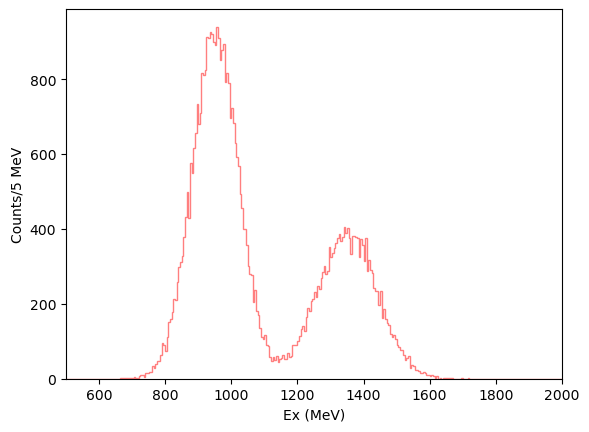

In [39]:
import numpy as np
import matplotlib.pyplot as plt

Ex = branches["Ex"]
xmin = 500
xmax = 2000
bin_width = 5.0
bins = np.arange(xmin, xmax + bin_width, bin_width)
plt.hist(Ex,bins=bins,histtype="step",color="red",linewidth=1,alpha=0.5)

plt.xlabel("Ex (MeV)")
plt.ylabel(f"Counts/{bin_width:g} MeV")

plt.xlim(xmin, xmax)
plt.show()

最小二乘拟合

Peak 1:
A = 32380.500741700882
mu = 950.5599728973333
sigma = 70.25839088939689
Peak 2:
A = 17606.056085953653
mu = 1350.197091790909
sigma = 90.58879797349243


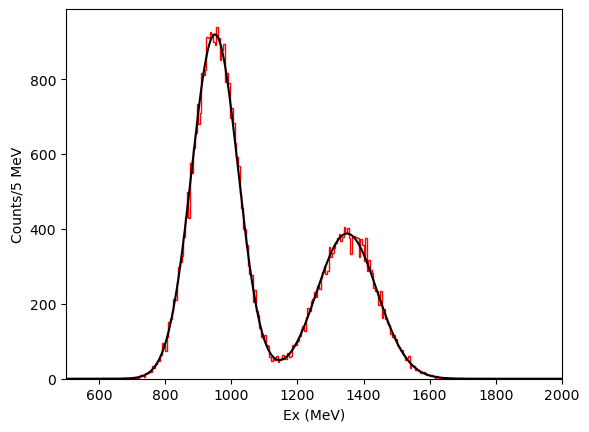

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit #非线性最小二乘拟合的函数

Ex = branches["Ex"]

xmin = 500
xmax = 2000
bin_width = 5.0
bins = np.arange(xmin, xmax + bin_width, bin_width)

#np.histogram()会一次返回两个结果（每个bin的计数，每一个bin的边界），所以 Python 可以用两个变量同时接收
counts, bin_edges = np.histogram(Ex, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# 双高斯函数
def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    g1 = A1 * bin_width / (np.sqrt(2 * np.pi) * sigma1) * \
         np.exp(-(x - mu1)**2 / (2 * sigma1**2))

    g2 = A2 * bin_width / (np.sqrt(2 * np.pi) * sigma2) * \
         np.exp(-(x - mu2)**2 / (2 * sigma2**2))

    return g1 + g2

# 初始参数
p0 = [counts[np.argmin(np.abs(bin_centers - 950))], 950, 50,
      counts[np.argmin(np.abs(bin_centers - 1350))], 1350, 50]

# 拟合,curve_fit是scipy中的固定函数
# curve_fit(拟合函数,x数据,y数据,初始参数)，返回popt = 最优拟合参数和pcov = 参数协方差矩阵
popt,pcov = curve_fit(double_gaussian,bin_centers,counts,p0=p0)

# 拟合参数
A1, mu1, sigma1, A2, mu2, sigma2 = popt

print("Peak 1:")
print("A =", A1)
print("mu =", mu1)
print("sigma =", sigma1)

print("Peak 2:")
print("A =", A2)
print("mu =", mu2)
print("sigma =", sigma2)

# 画原始能谱
plt.hist(Ex,bins=bins,histtype="step",color="red",linewidth=1)

# 画拟合曲线
x_fit = np.linspace(xmin, xmax, 2000)
plt.plot(x_fit, double_gaussian(x_fit, *popt), color="black")

plt.xlabel("Ex (MeV)")
plt.ylabel(f"Counts/{bin_width:g} MeV")
plt.xlim(xmin, xmax)

plt.show()